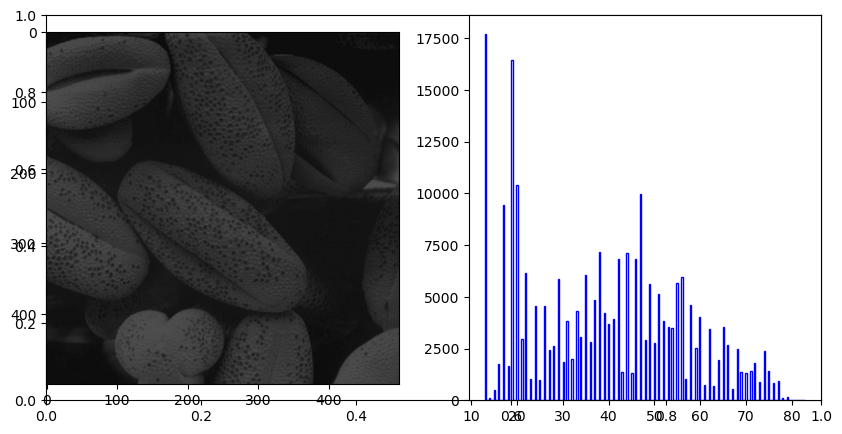

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

coffee = cv2.imread('coffee.tif', 0)
plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(coffee, vmin=0, vmax=255, cmap='gray')
plt.subplot(1,2,2)
plt.hist(coffee.ravel(), bins=256, histtype='step', color='blue')
plt.show()

In [6]:
import pandas as pd

hist, bins = np.histogram(coffee.ravel(), bins=256, range=[0, 256])
total_pixel = coffee.size
print("ukuran gambar:", coffee.shape)
print("total pixel/coffee.size:", total_pixel)
pdf=hist/total_pixel
cdf=pdf.cumsum()
cdf_normalized=np.round(cdf*255).astype(np.uint8)
coffee_eq_manual=cdf_normalized[coffee]
df = pd.DataFrame({
    "nilai_pixel": np.arange(256),
    "jumlah_pixel": hist,
    "pdf_probability": pdf,
    "cdf": cdf,
    "hasil_equalization": cdf_normalized
})

ukuran gambar: (500, 500)
total pixel/coffee.size: 250000


,nilai_pixel,jumlah_pixel,pdf_probability,cdf,hasil_equalization
13,13,17718,0.070872,0.070872,18
14,14,96,0.000384,0.071256,18
15,15,506,0.002024,0.073280,19
16,16,1750,0.007000,0.080280,20
17,17,9441,0.037764,0.118044,30
...,...,...,...,...,...
78,78,116,0.000464,0.999336,255
79,79,150,0.000600,0.999936,255
80,80,5,0.000020,0.999956,255
81,81,10,0.000040,0.999996,255


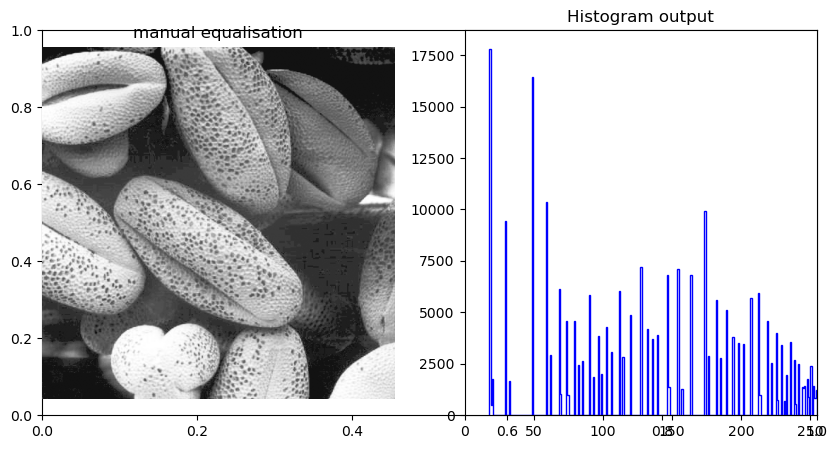

In [8]:
df_nonzero = df[df["jumlah_pixel"] > 0]
display(df_nonzero)
plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(coffee_eq_manual, vmin=0, vmax=255, cmap='gray')
plt.title("manual equalisation")
plt.axis("off")
plt.subplot(1,2,2)
plt.hist(coffee_eq_manual.ravel(), bins=256, histtype='step', color='blue')
plt.xlim(0,255)
plt.title("Histogram output")
plt.show()